In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = "/content/drive/MyDrive/deeplear final/PlantVillage"

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # делаем одинаковый размер
    transforms.ToTensor(),            # переводим в числа
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])  # нормализация
])

In [7]:
dataset = datasets.ImageFolder(root=data_path, transform=transform)

print("Classes:", dataset.classes)
print("Num classes:", len(dataset.classes))
print("Total images:", len(dataset))

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Num classes: 15
Total images: 20638


In [8]:
counter = Counter(dataset.targets)
print(counter)

Counter({12: 3208, 5: 2127, 7: 1909, 9: 1771, 10: 1676, 14: 1591, 1: 1478, 11: 1404, 2: 1000, 3: 1000, 6: 1000, 0: 997, 8: 952, 13: 373, 4: 152})


In [9]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

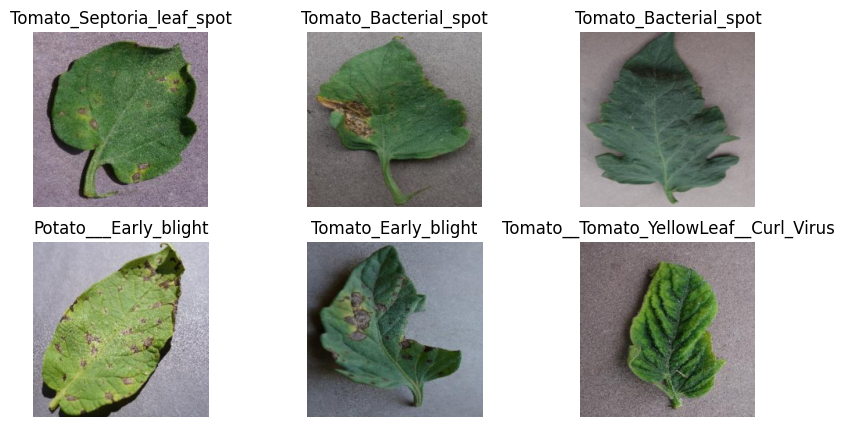

In [10]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5

    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.show()

In [11]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN(len(dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            _, pred = torch.max(out, 1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [14]:
import torch
print(torch.cuda.is_available())

True


In [15]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4
